SUPERVISED LEARNING: MODEL SELECTION PIPELINE
=======================================================================================
Bu kod bloğunun amacı, etiketlenmiş (Positive/Neutral/Negative) veri seti üzerinde 5 farklı makine öğrenmesi algoritmasını eğitip kıyaslamaktır.

Bu kodda şu adımlar uygulanmıştır:
1. Veri İzolasyonu (Train/Test Split): Modelin daha önce hiç görmediği verilerdeki 
   başarısını ölçmek için veri seti %80 Eğitim, %20 Test olarak ayrılmıştır.
2. Algoritma Doğası Gereği Ölçeklendirme: Ağaç tabanlı modeller (XGBoost, RF vb.) 
   ölçeklendirmeye ihtiyaç duymazken, mesafe tabanlı KNN algoritması için 
   StandardScaler kullanılmıştır.

Veri şu adresten okunuyor: ../data/gold_sentiment_analysis

=== MODELLER EĞİTİLİYOR VE MLFLOW'A KAYDEDİLİYOR ===


2026/05/13 17:56:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 17:56:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[+] LightGBM eğitildi ve MLflow'a loglandı. (Accuracy: 0.7181)


2026/05/13 17:56:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 17:56:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[+] XGBoost eğitildi ve MLflow'a loglandı. (Accuracy: 0.7225)


...

[+] CatBoost eğitildi ve MLflow'a loglandı. (Accuracy: 0.7182)


2026/05/13 17:56:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 17:56:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[+] Random Forest eğitildi ve MLflow'a loglandı. (Accuracy: 0.7090)


2026/05/13 17:57:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 17:57:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[+] KNN eğitildi ve MLflow'a loglandı. (Accuracy: 0.7008)

=== TÜM MODELLERİN SONUÇLARI ===
        Model  Accuracy  F1-Score  ROC-AUC  Time(s)
      XGBoost  0.722493  0.738042 0.875831 2.179472
     CatBoost  0.718230  0.733138 0.873081 3.941923
     LightGBM  0.718128  0.734905 0.875086 1.834194
Random Forest  0.708993  0.725697 0.861920 1.522860
          KNN  0.700771  0.712051 0.843211 1.757293


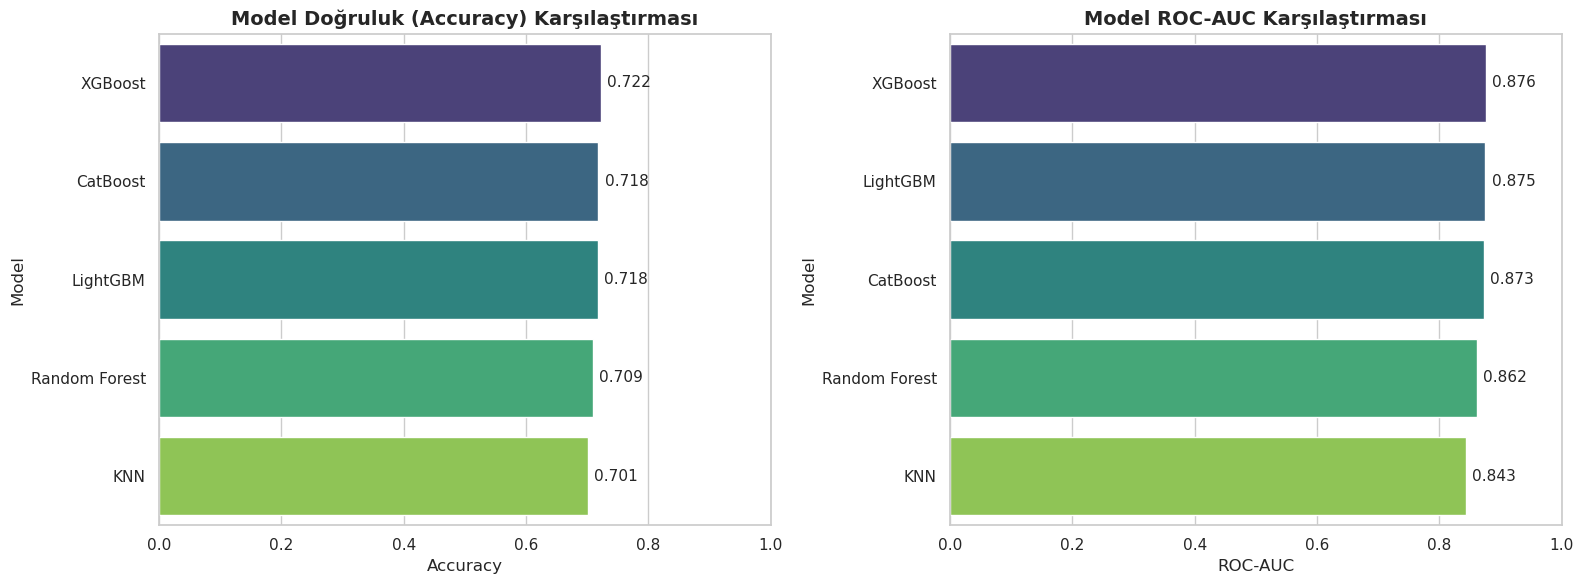


=== AĞAÇ TABANLI MODELLER İÇİN ÖZELLİK ÖNEMİ ÇIKARILIYOR ===


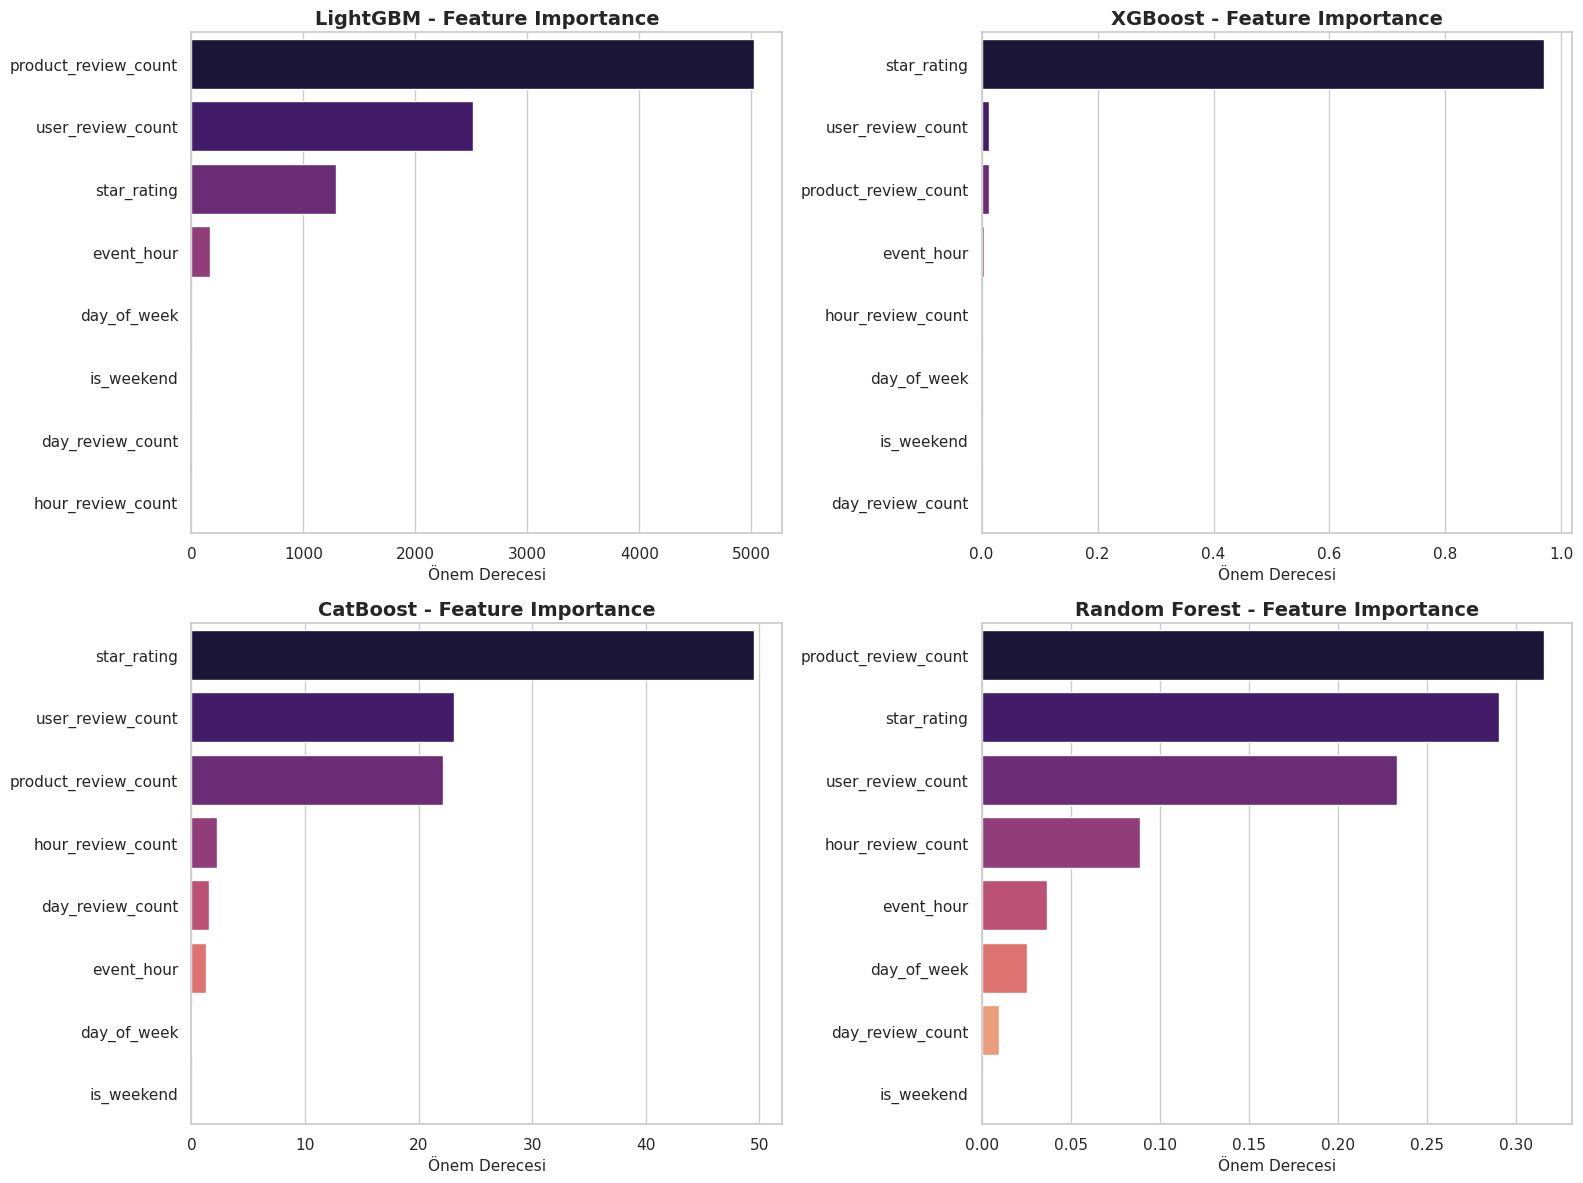

In [3]:
"""
=======================================================================================
 SUPERVISED LEARNING: MODEL KIYASLAMA VE MLFLOW ENTEGRASYONU (STEP 6)
=======================================================================================
Bu kod bloğu, 5 farklı sınıflandırma algoritmasını eğitir ve PDF'te istenen 
tüm metrikleri (Accuracy, F1, Precision, Recall, ROC-AUC) hesaplar.
Ayrıca her bir deney (experiment), model ve confusion matrix MLflow'a kaydedilir.
=======================================================================================
"""

# ==========================================
# 1. KÜTÜPHANELER VE KONFİGÜRASYON
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import warnings
import warnings
warnings.filterwarnings("ignore")
# MLflow ve Spark
import mlflow
import mlflow.sklearn
from pyspark.sql import SparkSession

# Makine Öğrenmesi
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix

# Modeller
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

warnings.filterwarnings("ignore")

# ==========================================
# 2. VERİ YÜKLEME 
# ==========================================
spark = SparkSession.builder \
    .appName("ML_Comparison_Pipeline") \
    .config("spark.driver.memory", "2g") \
    .config("spark.jars.packages", "io.delta:delta-spark_2.12:3.1.0") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .getOrCreate()

gold_path = "../data/gold_sentiment_analysis"
print(f"Veri şu adresten okunuyor: {gold_path}")

df_spark = spark.read.format("delta").load(gold_path)

selected_features = [
    "star_rating", "event_hour", "day_of_week", "is_weekend",
    "user_review_count", "product_review_count", "day_review_count", 
    "hour_review_count", "sentiment_label"
]
df = df_spark.select(selected_features).toPandas()
spark.stop()

# ==========================================
# 3. ÖN İŞLEME (PREPROCESSING)
# ==========================================
label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
df['target'] = df['sentiment_label'].map(label_map)

X = df.drop(['sentiment_label', 'target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 4. MODEL EĞİTİMİ VE MLFLOW LOGLAMA
# ==========================================
models = {
    "LightGBM": lgb.LGBMClassifier(learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1),
    "XGBoost": xgb.XGBClassifier(eval_metric='mlogloss', random_state=42),
    "CatBoost": CatBoostClassifier(iterations=100, verbose=0, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

results = []

# MLflow Deneyini (Experiment) Ayarla
mlflow.set_experiment("Amazon_Sentiment_Analysis_Project")

print("\n=== MODELLER EĞİTİLİYOR VE MLFLOW'A KAYDEDİLİYOR ===")

for name, model in models.items():
    # Her model için ayrı bir MLflow kaydı başlatıyoruz
    with mlflow.start_run(run_name=name):
        start = time.time()
        
        # Eğitim ve Tahmin (KNN için ölçeklenmiş veri)
        if name == "KNN":
            model.fit(X_train_scaled, y_train)
            preds = model.predict(X_test_scaled)
            probs = model.predict_proba(X_test_scaled) # ROC-AUC için olasılıklar
        else:
            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            probs = model.predict_proba(X_test)
        
        runtime = time.time() - start
        
        # PDF'te İstenen Tüm Metriklerin Hesaplanması (Multi-class oldukları için 'macro' kullanıyoruz)
        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average='macro')
        prec = precision_score(y_test, preds, average='macro')
        rec = recall_score(y_test, preds, average='macro')
        roc_auc = roc_auc_score(y_test, probs, multi_class='ovr', average='macro')
        
        # 1. MLflow: Metrikleri Logla
        mlflow.log_metric("Accuracy", acc)
        mlflow.log_metric("F1_Score", f1)
        mlflow.log_metric("Precision", prec)
        mlflow.log_metric("Recall", rec)
        mlflow.log_metric("ROC_AUC", roc_auc)
        mlflow.log_metric("Training_Time_sec", runtime)
        
        # 2. MLflow: Modeli Logla
        mlflow.sklearn.log_model(model, f"{name}_model")
        
        # 3. Confusion Matrix Çizimi ve MLflow'a Artifact Olarak Kaydedilmesi
        cm = confusion_matrix(y_test, preds)
        plt.figure(figsize=(6, 4))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
        plt.title(f"{name} Confusion Matrix")
        plt.ylabel('Gerçek Değerler')
        plt.xlabel('Tahmin Edilen Değerler')
        plt.tight_layout()
        
        cm_file = f"{name}_confusion_matrix.png"
        plt.savefig(cm_file) # Resmi kaydet
        mlflow.log_artifact(cm_file) # MLflow'a gönder
        plt.close() # Ekranda kalabalık yapmasın diye kapat
        
        # Genel sonuç tablosu için listeye ekle
        results.append({
            "Model": name,
            "Accuracy": acc,
            "F1-Score": f1,
            "ROC-AUC": roc_auc,
            "Time(s)": runtime
        })
        print(f"[+] {name} eğitildi ve MLflow'a loglandı. (Accuracy: {acc:.4f})")

# ==========================================
# 5. SONUÇLARIN GÖRSELLEŞTİRİLMESİ
# ==========================================
results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False)
print("\n=== TÜM MODELLERİN SONUÇLARI ===")
print(results_df.to_string(index=False))

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = sns.color_palette("viridis", len(models))

sns.barplot(x="Accuracy", y="Model", data=results_df, ax=axes[0], palette=palette)
axes[0].set_title("Model Doğruluk (Accuracy) Karşılaştırması", fontsize=14, fontweight='bold')
axes[0].set_xlim(0, 1.0)
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_width():.3f}", (p.get_width() + 0.01, p.get_y() + p.get_height() / 2), ha='left', va='center', fontsize=11)

sns.barplot(x="ROC-AUC", y="Model", data=results_df.sort_values("ROC-AUC", ascending=False), ax=axes[1], palette=palette)
axes[1].set_title("Model ROC-AUC Karşılaştırması", fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 1.0)
for p in axes[1].patches:
    axes[1].annotate(f"{p.get_width():.3f}", (p.get_width() + 0.01, p.get_y() + p.get_height() / 2), ha='left', va='center', fontsize=11)

plt.tight_layout()
plt.show()

# ==========================================
# 6. FEATURE IMPORTANCE (ÖZELLİK ÖNEMİ)
# ==========================================
print("\n=== AĞAÇ TABANLI MODELLER İÇİN ÖZELLİK ÖNEMİ ÇIKARILIYOR ===")

tree_models = {k: v for k, v in models.items() if k != "KNN"}
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (name, model) in enumerate(tree_models.items()):
    if name == "CatBoost":
        importances = model.get_feature_importance()
    else:
        importances = model.feature_importances_
        
    imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    
    sns.barplot(x='Importance', y='Feature', data=imp_df, ax=axes[idx], palette='magma')
    axes[idx].set_title(f"{name} - Feature Importance", fontsize=14, fontweight='bold')
    axes[idx].set_xlabel("Önem Derecesi", fontsize=11)
    axes[idx].set_ylabel("")

plt.tight_layout()
plt.show()

In [2]:
# Veri setinin tam boyutunu  kontrol et
# İlk 5 ve Son 5 satırı göster 
display(df)

,star_rating,event_hour,day_of_week,is_weekend,user_review_count,product_review_count,day_review_count,hour_review_count,sentiment_label,target
0,5.0,13,2,0,4,3,44260,21101,Neutral,1
1,5.0,12,2,0,2,108,44260,18159,Neutral,1
2,3.0,13,2,0,2,11,44260,21101,Neutral,1
3,5.0,13,2,0,1,3,44260,21101,Neutral,1
4,5.0,12,2,0,2,1006,44260,18159,Neutral,1
...,...,...,...,...,...,...,...,...,...,...
49255,0.0,13,2,0,12859,12859,44260,21101,Negative,0
49256,0.0,13,2,0,12859,12859,44260,21101,Negative,0
49257,0.0,13,2,0,12859,12859,44260,21101,Negative,0
49258,0.0,13,2,0,12859,12859,44260,21101,Negative,0


K-MEANS ile MÜŞTERİ SEGMENTASYONU (GÖZETİMSİZ ÖĞRENME)
=======================================================================================
Bu kod bloğunun amacı, verisetimizdeki müşterileri davranışlarına göre 
3 farklı kümeye ayırmaktır.
Büyük veri ile çalışılması nedeni ile koda şu optimizasyonlar eklenmiştir:
1. Ölçeklendirme (StandardScaler): K-Means uzaklık ölçerek çalışır. "Yorum Sayısı" gibi 
   büyük sayıların, Yıldız Puanını (1-5) ezmemesi için tüm veriler aynı ölçeğe getirildi.
2. Gizli Özellik Keşfi (Random Forest): K-Means kümeleri ayırır ama nedenini söylemez. 
   Bu yüzden kümeler oluştuktan sonra bir Random Forest modeli eğitilerek, bu 3 profili 
   birbirinden ayıran en önemli özellikler (Feature Importance) tespit edildi.
3. Görselleştirme Optimizasyonu: 49 bin noktanın hepsini grafiğe basmak bilgisayarı 
   kilitleyeceği (overplotting) için, dağılım grafiği (Scatter Plot) verinin rastgele 
   seçilmiş %5'lik bir örneklemi üzerinden çizdirildi.

Veri K-Means için hazırlanıyor (VectorAssembler & StandardScaler)...
K-Means Modeli 49 Bin Satır üzerinde eğitiliyor...

[BAŞARILI] K-Means (k=3) Silhouette Skoru: 0.9079
(Not: Bu skor -1 ile 1 arasındadır. 1'e ne kadar yakınsa kümeler o kadar iyi ayrışmış demektir.)


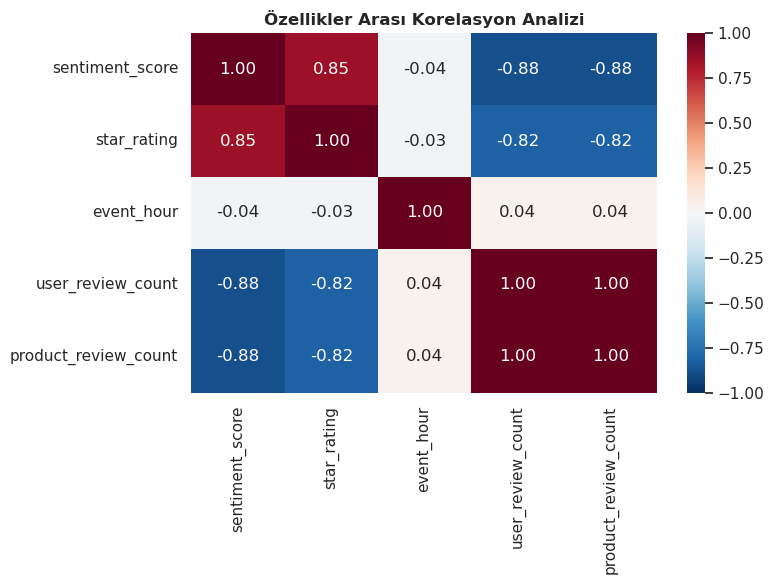


K-Means Kümelerini Açıklayan Özelliklerin Önemi Hesaplanıyor...


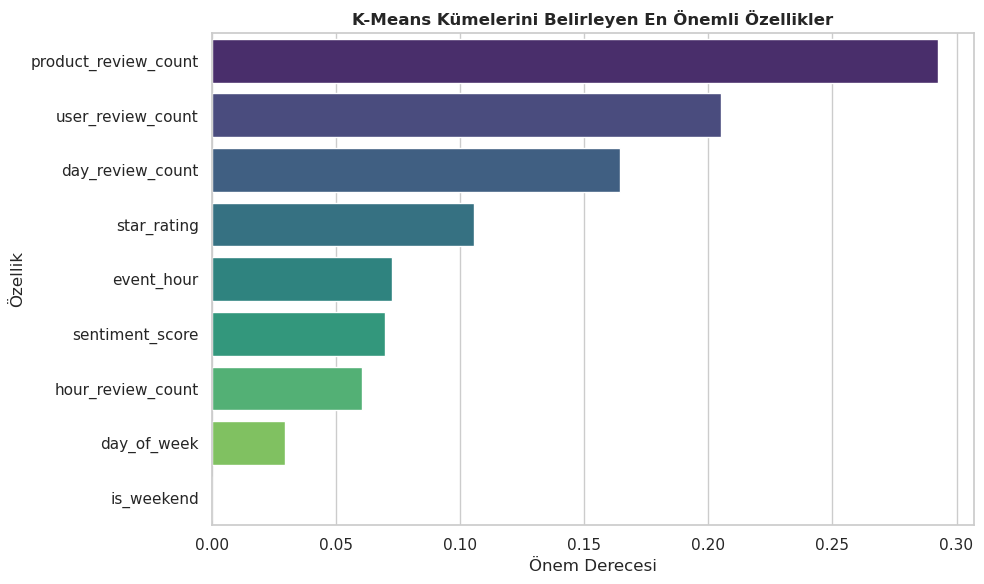

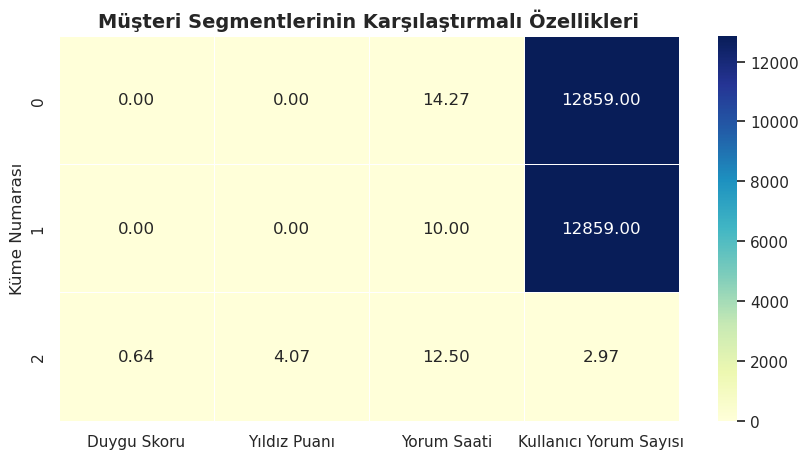

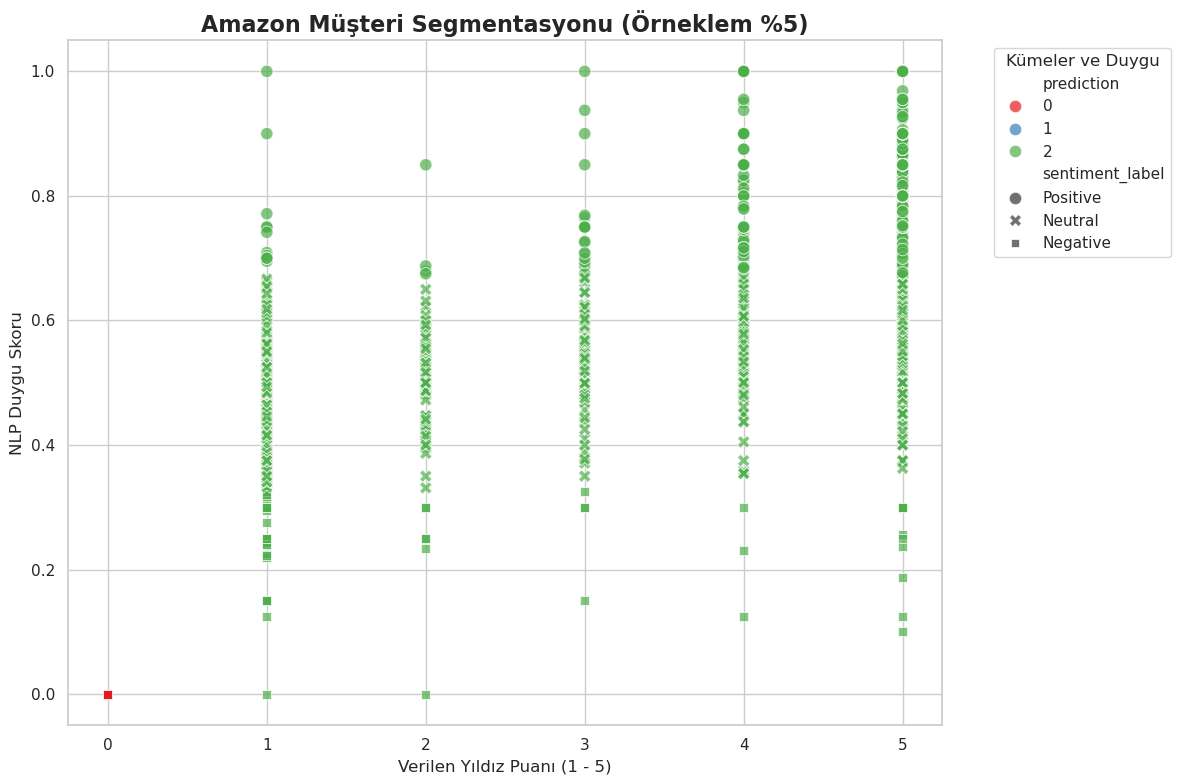

In [5]:
# ==========================================
# 1. KÜTÜPHANELER VE VERİ YÜKLEME
# ==========================================
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.classification import RandomForestClassifier
from pyspark.sql.functions import avg
import warnings
warnings.filterwarnings("ignore")
# Spark Oturumu
spark = SparkSession.builder \
    .appName("KMeans_Segmentation") \
    .config("spark.driver.memory", "2g") \
    .config("spark.jars.packages", "io.delta:delta-spark_2.12:3.1.0") \
    .config("spark.sql.extensions", "io.delta.sql.DeltaSparkSessionExtension") \
    .config("spark.sql.catalog.spark_catalog", "org.apache.spark.sql.delta.catalog.DeltaCatalog") \
    .getOrCreate()

gold_path = "../data/gold_sentiment_analysis"
df_spark = spark.read.format("delta").load(gold_path)

# ==========================================
# 2. K-MEANS İÇİN ÖN İŞLEME (ÖLÇEKLENDİRME)
# ==========================================
print("Veri K-Means için hazırlanıyor (VectorAssembler & StandardScaler)...")

# Modele girecek sayısal özellikler
feature_cols = [
    'sentiment_score', 'star_rating', 'event_hour', 
    'day_of_week', 'is_weekend', 'user_review_count',
    'product_review_count', 'day_review_count', 'hour_review_count'
]

# 1. Özellikleri tek bir vektörde topla
assembler = VectorAssembler(inputCols=feature_cols, outputCol="raw_features")
df_assembled = assembler.transform(df_spark)

# 2. K-Means mesafe tabanlı olduğu için verileri standartlaştır (Çok Önemli!)
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=True)
scaler_model = scaler.fit(df_assembled)
df_scaled = scaler_model.transform(df_assembled)

# ==========================================
# 3. K-MEANS MODEL EĞİTİMİ VE DEĞERLENDİRME
# ==========================================
print("K-Means Modeli 49 Bin Satır üzerinde eğitiliyor...")
kmeans = KMeans(featuresCol="features", predictionCol="prediction", k=3, seed=42)
kmeans_model = kmeans.fit(df_scaled)
predictions = kmeans_model.transform(df_scaled)

evaluator = ClusteringEvaluator(featuresCol="features", predictionCol="prediction")
silhouette = evaluator.evaluate(predictions)

print(f"\n[BAŞARILI] K-Means (k=3) Silhouette Skoru: {silhouette:.4f}")
print("(Not: Bu skor -1 ile 1 arasındadır. 1'e ne kadar yakınsa kümeler o kadar iyi ayrışmış demektir.)")

# ==========================================
# 4. KORELASYON ANALİZİ GRAFİĞİ
# ==========================================
features_for_corr = ['sentiment_score', 'star_rating', 'event_hour', 'user_review_count', 'product_review_count']
corr_df = predictions.select(*features_for_corr).toPandas().corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt=".2f")
plt.title("Özellikler Arası Korelasyon Analizi", fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 5. FEATURE IMPORTANCE (RANDOM FOREST İLE)
# ==========================================
print("\nK-Means Kümelerini Açıklayan Özelliklerin Önemi Hesaplanıyor...")
rf = RandomForestClassifier(labelCol="prediction", featuresCol="features", predictionCol="rf_prediction", numTrees=20, seed=42)
rf_model = rf.fit(predictions)

importances = rf_model.featureImportances.toArray()
importance_df = pd.DataFrame({'Özellik': feature_cols, 'Önem Derecesi': importances})
importance_df = importance_df.sort_values(by='Önem Derecesi', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Önem Derecesi', y='Özellik', palette='viridis')
plt.title("K-Means Kümelerini Belirleyen En Önemli Özellikler", fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 6. KÜMELERİN ORTALAMA ÖZELLİKLERİ (ISI HARİTASI)
# ==========================================
# Not: Hangi kümenin (0, 1, 2) hangi profile uyduğunu bu haritaya bakarak anlayacağız.
cluster_features = predictions.groupBy("prediction").agg(
    avg("sentiment_score").alias("Duygu Skoru"),
    avg("star_rating").alias("Yıldız Puanı"),
    avg("event_hour").alias("Yorum Saati"),
    avg("user_review_count").alias("Kullanıcı Yorum Sayısı")
).toPandas()

cluster_features = cluster_features.set_index('prediction').sort_index()

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_features, annot=True, cmap='YlGnBu', fmt=".2f", linewidths=.5)
plt.title('Müşteri Segmentlerinin Karşılaştırmalı Özellikleri', fontsize=14, fontweight='bold')
plt.ylabel("Küme Numarası")
plt.show()

# ==========================================
# 7. KÜMELERİN DAĞILIMI (SCATTER PLOT)
# ==========================================
# BİLGİSAYAR MÜHENDİSLİĞİ DOKUNUŞU: 49 bin satırı scatter plot'a basmak üst üste binme (overplotting) yapar.
# Dağılımı net görmek için verinin %5'ini (yaklaşık 2500 satır) örnekliyoruz.
sampled_predictions = predictions.sample(fraction=0.05, seed=42)

predictions_pd = sampled_predictions.select(
    'star_rating', 'sentiment_score', 'sentiment_label', 'prediction'
).toPandas()

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

scatter = sns.scatterplot(
    data=predictions_pd,
    x='star_rating', 
    y='sentiment_score', 
    hue='prediction', # Küme numarasına göre renklendirme
    style='sentiment_label', 
    palette='Set1', 
    s=80, 
    alpha=0.7 
)
plt.title('Amazon Müşteri Segmentasyonu (Örneklem %5)', fontsize=16, fontweight='bold')
plt.xlabel('Verilen Yıldız Puanı (1 - 5)', fontsize=12)
plt.ylabel('NLP Duygu Skoru', fontsize=12)
plt.legend(title='Kümeler ve Duygu', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# İşlem bitince RAM'i temizle
spark.stop()

Veri şu adresten okunuyor: ../data/gold_sentiment_analysis


2026/05/13 17:51:29 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/13 17:51:29 INFO mlflow.store.db.utils: Updating database tables
2026/05/13 17:51:32 INFO mlflow.tracking.fluent: Experiment with name 'Amazon_Sentiment_Analysis_Project' does not exist. Creating a new experiment.



=== MODELLER EĞİTİLİYOR VE MLFLOW'A KAYDEDİLİYOR ===


2026/05/13 17:51:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 17:51:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[+] LightGBM eğitildi ve MLflow'a loglandı. (Accuracy: 0.7181)


...

[+] CatBoost eğitildi ve MLflow'a loglandı. (Accuracy: 0.7182)


2026/05/13 17:52:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 17:52:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[+] Random Forest eğitildi ve MLflow'a loglandı. (Accuracy: 0.7090)


2026/05/13 17:52:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 17:52:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


[+] KNN eğitildi ve MLflow'a loglandı. (Accuracy: 0.7008)

=== TÜM MODELLERİN SONUÇLARI ===
        Model  Accuracy  F1-Score  ROC-AUC  Time(s)
      XGBoost  0.722493  0.738042 0.875831 1.694063
     CatBoost  0.718230  0.733138 0.873081 1.090035
     LightGBM  0.718128  0.734905 0.875086 2.129569
Random Forest  0.708993  0.725697 0.861920 1.315732
          KNN  0.700771  0.712051 0.843211 1.018079


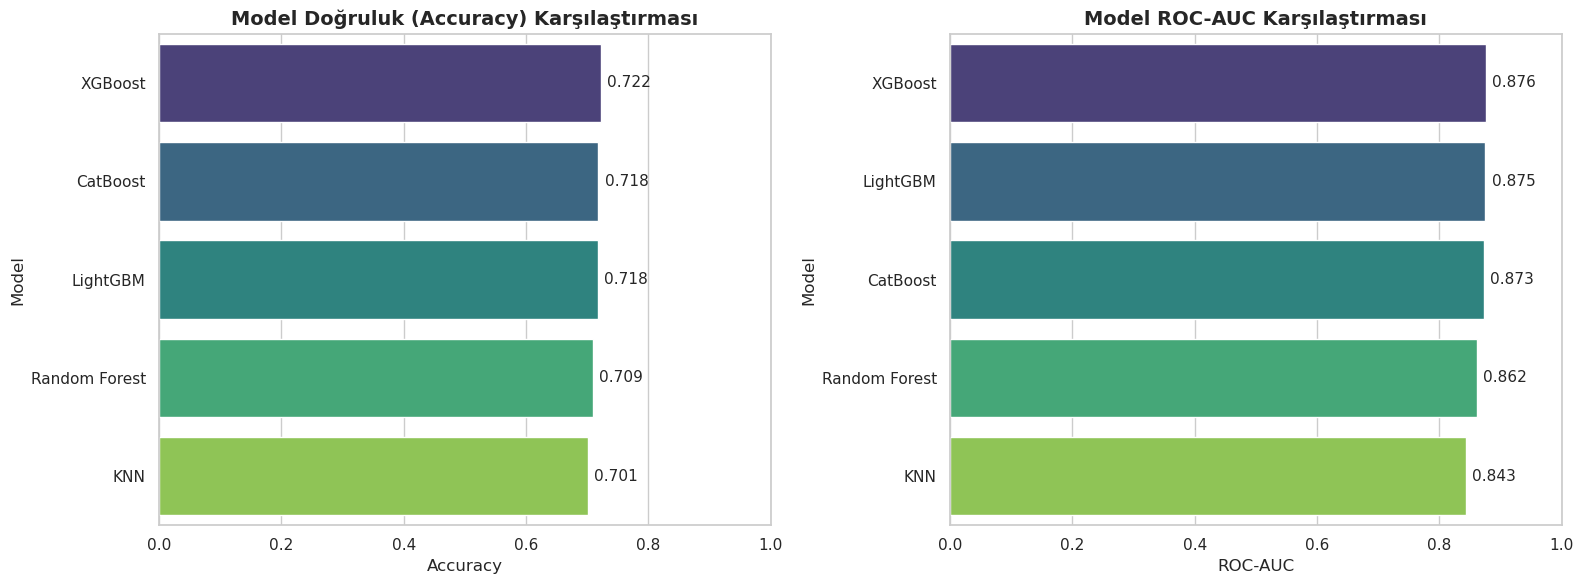


=== AĞAÇ TABANLI MODELLER İÇİN ÖZELLİK ÖNEMİ ÇIKARILIYOR ===


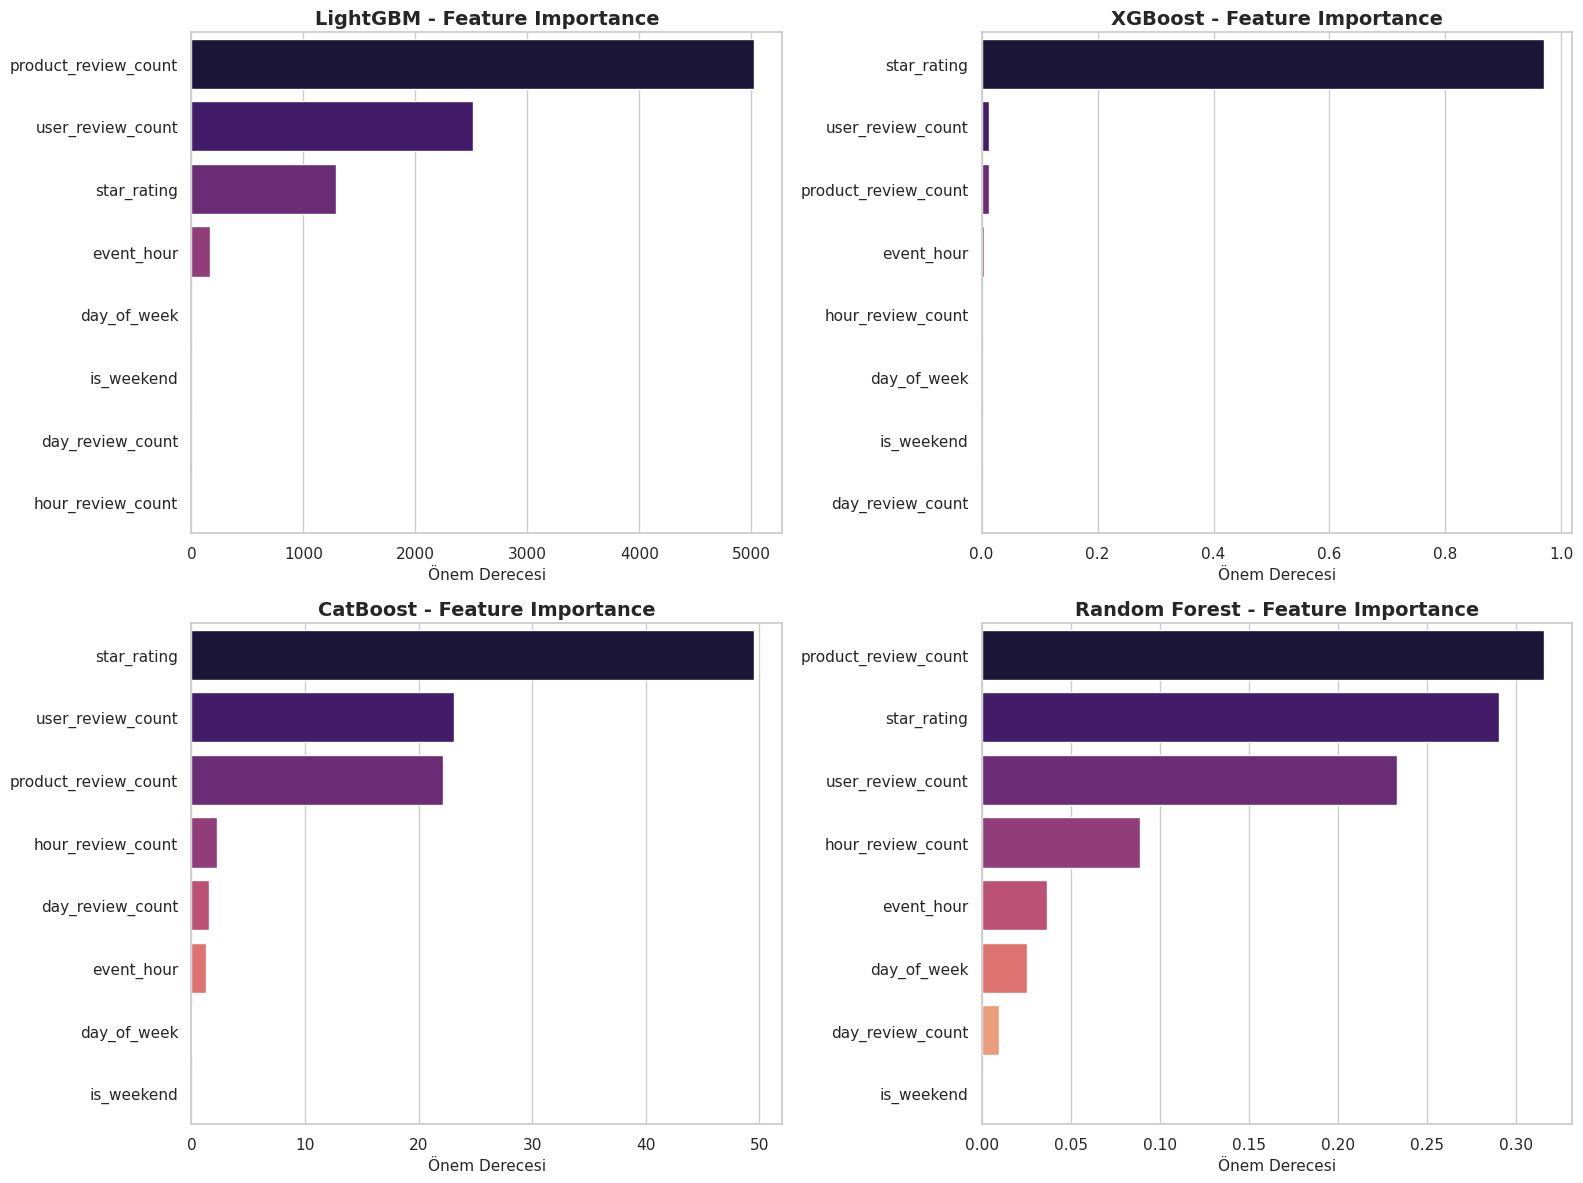

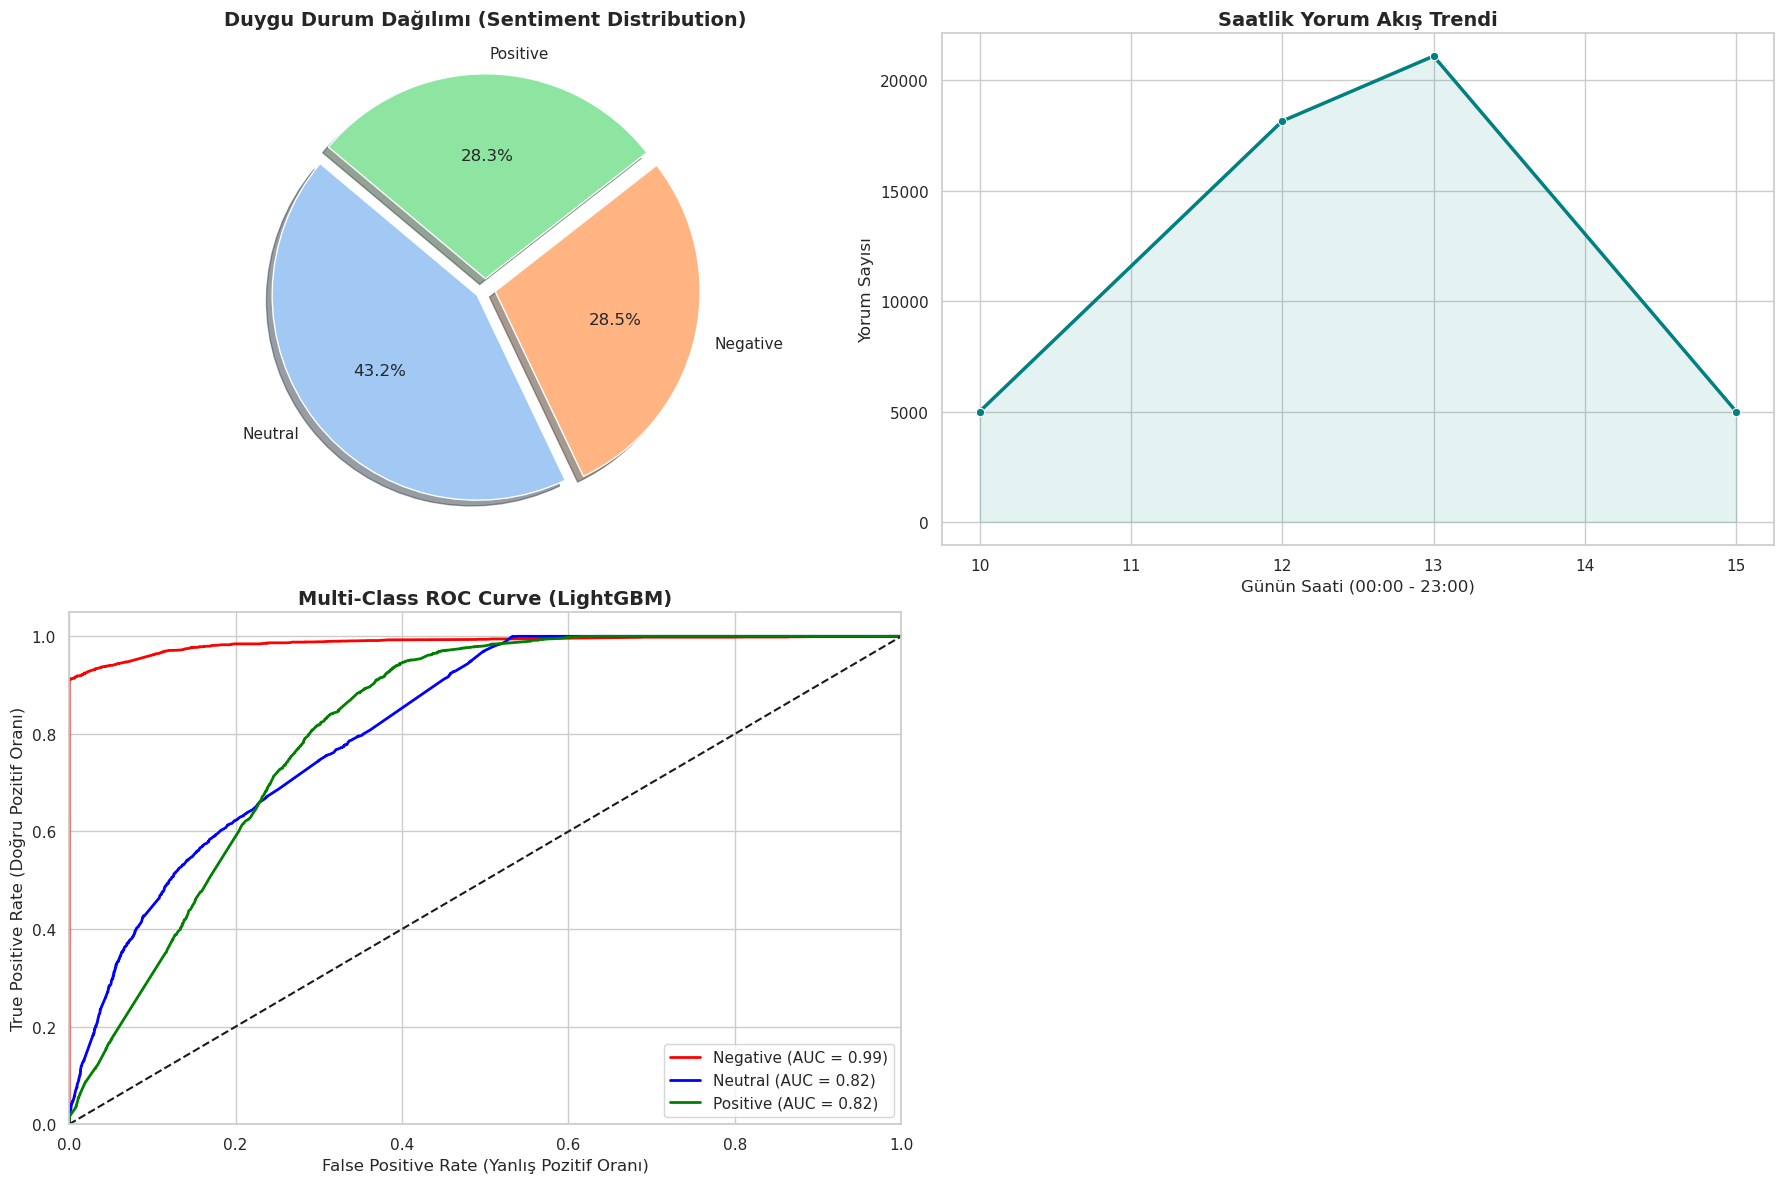

In [2]:
# ==========================================
# 7. GÖRSELLEŞTİRME VE DASHBOARD (ADIM 7)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Grafik Stilini Ayarla
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 12))

# --- 1. DAĞILIM GRAFİĞİ (PIE CHART) ---
plt.subplot(2, 2, 1)
sentiment_counts = df['sentiment_label'].value_counts()
colors = sns.color_palette('pastel')[0:3]
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors, explode=(0.05, 0.05, 0.05), shadow=True)
plt.title("Duygu Durum Dağılımı (Sentiment Distribution)", fontsize=14, fontweight='bold')

# --- 2. ZAMAN SERİSİ TREND GRAFİĞİ (LINE CHART) ---
plt.subplot(2, 2, 2)
# Saatlik yorum akışını hesapla
hourly_trend = df.groupby('event_hour').size().reset_index(name='review_count')
sns.lineplot(data=hourly_trend, x='event_hour', y='review_count', marker='o', color='teal', linewidth=2.5)
plt.fill_between(hourly_trend['event_hour'], hourly_trend['review_count'], color='teal', alpha=0.1)
plt.title("Saatlik Yorum Akış Trendi", fontsize=14, fontweight='bold')
plt.xlabel("Günün Saati (00:00 - 23:00)")
plt.ylabel("Yorum Sayısı")

# --- 3. ROC CURVE GRAFİĞİ (EN İYİ MODEL İÇİN) ---
plt.subplot(2, 2, 3)
# Not: LightGBM'in en iyi sonuçlardan birini verdiğini varsayarak onun ROC eğrisini çiziyoruz
best_model = models["LightGBM"]
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score = best_model.predict_proba(X_test)

n_classes = 3
colors = ['red', 'blue', 'green']
labels = ['Negative', 'Neutral', 'Positive']

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)')
plt.title('Multi-Class ROC Curve (LightGBM)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [4]:
import joblib

# Eğittiğimiz en iyi model olan LightGBM'i seçiyoruz
best_model = models["LightGBM"]

# Modeli projenin ana dizinine "pkl" (pickle) formatında kaydediyoruz
kayit_yolu = "../lightgbm_sentiment_model.pkl"
joblib.dump(best_model, kayit_yolu)

print(f"Model başarıyla kaydedildi: {kayit_yolu}")

Model başarıyla kaydedildi: ../lightgbm_sentiment_model.pkl


In [ ]:
import joblib
import pandas as pd

# 1. SUNUM BAŞLARKEN MODELİ HAFIZAYA AL (Sadece 1 kere çalışır)
print("Kaydedilmiş LightGBM modeli canlı sistem için yükleniyor...")
loaded_model = joblib.load("lightgbm_sentiment_model.pkl")

# Duygu sözlüğümüz
duygu_sozlugu = {0: "NEGATİF", 1: "NÖTR", 2: "POZİTİF"}

# 2. KAFKA'DAN HER YENİ VERİ GELDİĞİNDE ÇALIŞACAK KISIM
def canli_tahmin_yap(gelen_spark_df, epoch_id):
    # Eğer gelen veri boş değilse
    if gelen_spark_df.count() > 0:
        
        # Modele girecek özellikleri seç ve Pandas'a çevir
        canli_veri = gelen_spark_df.select(
            "star_rating", "event_hour", "day_of_week", "is_weekend",
            "user_review_count", "product_review_count", "day_review_count", "hour_review_count"
        ).toPandas()
        
        # Modeli çalıştır ve tahmin al!
        tahminler = loaded_model.predict(canli_veri)
        
        # Sonucu ekrana şık bir şekilde yazdır
        for i, tahmin in enumerate(tahminler):
            yildiz = canli_veri.iloc[i]['star_rating']
            sonuc_metni = duygu_sozlugu[tahmin]
            print(f"YENİ YORUM GELDİ! -> Verilen Puan: {yildiz} Yıldız | Modelin Kararı: {sonuc_metni}")

# Spark Streaming formatında bu fonksiyonu çağırıyoruz
# streaming_df.writeStream.foreachBatch(canli_tahmin_yap).start().awaitTermination()